In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/pedro/miniconda3/envs/cloelite/lib/python3.9/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Cosmology: Background + Perturbations

Shows how to use CAMB and HMCode2020emu

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


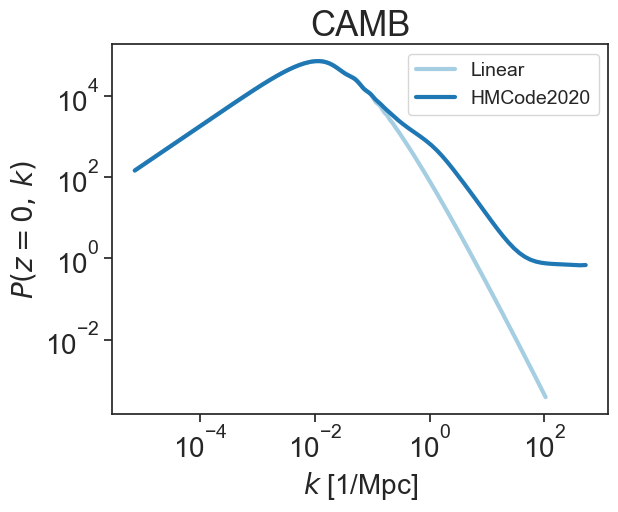

In [2]:
zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_values_linear = linear_perturbations.matter_power_spectrum(linear_perturbations.z,linear_perturbations.k)

nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = 'mead2020_feedback')
pk_values_nonlinear = nonlinear_perturbations.matter_power_spectrum(nonlinear_perturbations.z,nonlinear_perturbations.k)

plt.loglog(linear_perturbations.k, pk_values_linear[0, :], label='Linear');
plt.loglog(nonlinear_perturbations.k, pk_values_nonlinear[0, :], label='HMCode2020');
plt.xlabel(r'$k$ [1/Mpc]');
plt.ylabel(r'$P(z=0, \, k)$');
plt.title('CAMB');
plt.legend();

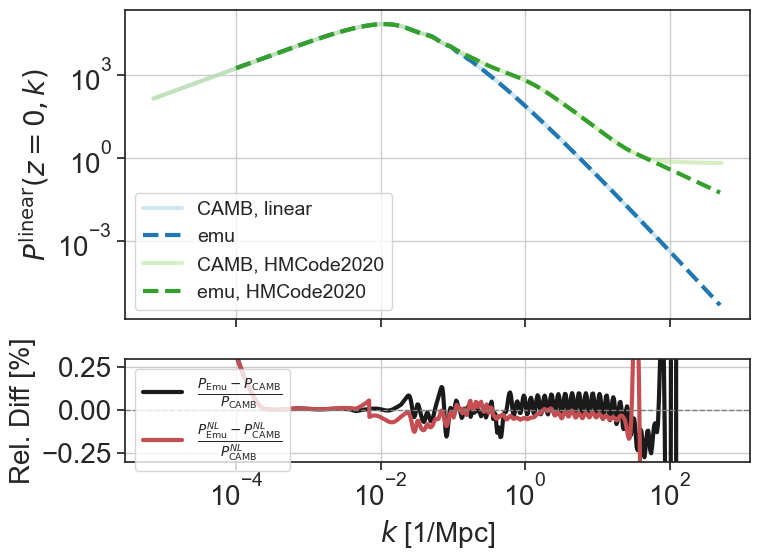

In [3]:
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)
pk_values_linear_emu = linear_perturbations_emu.matter_power_spectrum(linear_perturbations_emu.z,linear_perturbations_emu.k)

pk_values_nonlinear_emu = nonlinear_perturbations_emu.matter_power_spectrum(nonlinear_perturbations_emu.z,nonlinear_perturbations_emu.k)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

# First plot: Power spectra
ax[0].loglog(linear_perturbations.k, pk_values_linear[0, :], label='CAMB, linear', alpha=0.5)
ax[0].loglog(linear_perturbations_emu.k, pk_values_linear_emu[0, :], '--', label='emu')
ax[0].loglog(nonlinear_perturbations.k, pk_values_nonlinear[0, :], label='CAMB, HMCode2020', alpha=0.5)
ax[0].loglog(nonlinear_perturbations_emu.k, pk_values_nonlinear_emu[0, :], '--', label='emu, HMCode2020')

ax[0].set_ylabel(r'$P^{\rm linear}(z=0, k)$')
ax[0].legend()
ax[0].grid()

# Compute relative difference
interp_camb = interp1d(linear_perturbations.k, pk_values_linear[0, :], kind='cubic', bounds_error=False, fill_value="extrapolate")
pk_camb_interp = interp_camb(linear_perturbations_emu.k)

relative_diff = 100*(pk_values_linear_emu[0, :] - pk_camb_interp) / pk_camb_interp

interp_camb_nl = interp1d(nonlinear_perturbations.k, pk_values_nonlinear[0, :], kind='cubic', bounds_error=False, fill_value="extrapolate")
pk_camb_interp_nl = interp_camb_nl(nonlinear_perturbations_emu.k)

relative_diff_nl = 100*(pk_values_nonlinear_emu[0, :] - pk_camb_interp_nl) / pk_camb_interp_nl

# Second plot: Relative difference
ax[1].semilogx(linear_perturbations_emu.k, relative_diff, 'k-', label=r'$\frac{P_{\mathrm{Emu}} - P_{\mathrm{CAMB}}}{P_{\mathrm{CAMB}}}$')
ax[1].semilogx(nonlinear_perturbations_emu.k, relative_diff_nl, 'r-', label=r'$\frac{P^{NL}_{\mathrm{Emu}} - P^{NL}_{\mathrm{CAMB}}}{P^{NL}_{\mathrm{CAMB}}}$')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$k$ [1/Mpc]')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()
ax[1].set_ylim([-0.3,0.3])

plt.tight_layout()
plt.show()


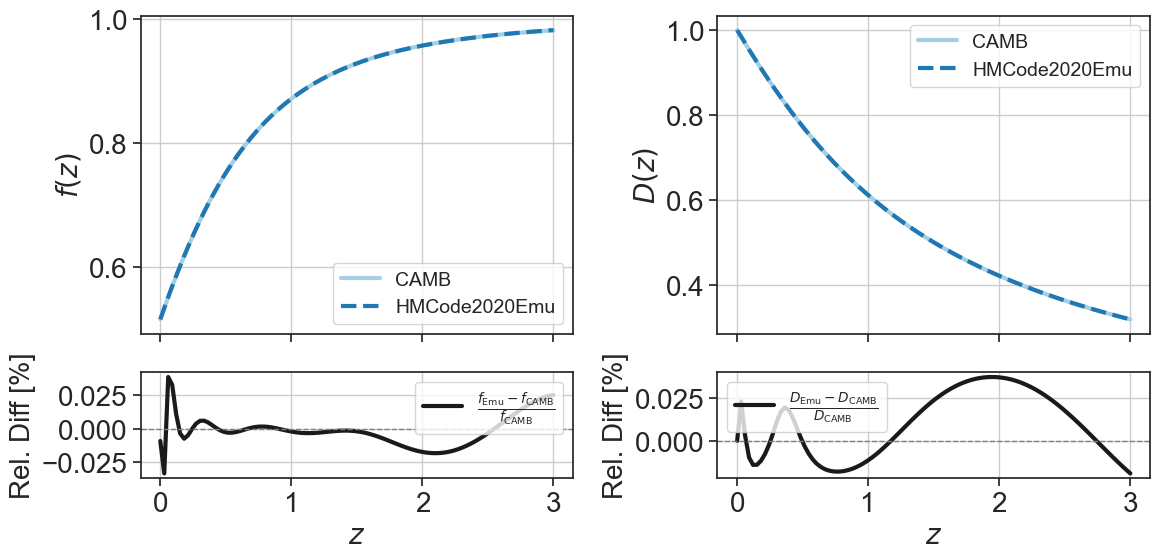

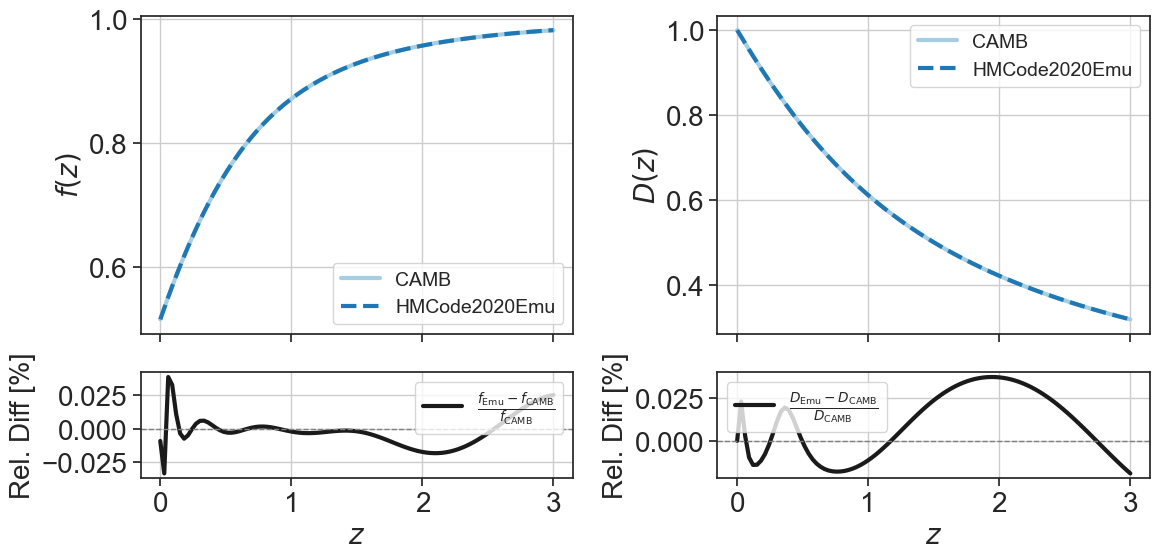

In [4]:
def plot_growth_comparison(camb_perturbations, emu_perturbations):
    """
    Plots the growth rate and growth factor comparisons between CAMB and HMCode2020Emu.
    
    Parameters:
    - camb_perturbations: Object containing growth rate and growth factor from CAMB.
    - emu_perturbations: Object containing growth rate and growth factor from HMCode2020Emu.
    """
    
    fig, ax = plt.subplots(2, 2, sharex=True, figsize=(12, 6), gridspec_kw={'height_ratios': [3, 1]})
    z_emu = emu_perturbations.params_hm_emu['z']
    # Growth rate comparison (Left panel)
    ax[0, 0].plot(camb_perturbations.z[::-1], camb_perturbations.growth_rate(), label='CAMB')
    ax[0, 0].plot(z_emu, 
                  emu_perturbations.growth_rate(), 
                  '--', 
                  label='HMCode2020Emu')

    ax[0, 0].set_ylabel(r'$f(z)$')
    ax[0, 0].legend()
    ax[0, 0].grid()

    # Compute relative difference for growth rate
    growth_camb = camb_perturbations.growth_rate()
    growth_emu = emu_perturbations.growth_rate()

    interp_camb = interp1d(camb_perturbations.z[::-1], growth_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    growth_camb_interp = interp_camb(z_emu)

    relative_diff_rate = 100 * (growth_emu - growth_camb_interp) / growth_camb_interp

    ax[1, 0].plot(z_emu, relative_diff_rate, 'k-', label=r'$\frac{f_{\mathrm{Emu}} - f_{\mathrm{CAMB}}}{f_{\mathrm{CAMB}}}$')
    ax[1, 0].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[1, 0].set_xlabel(r'$z$')
    ax[1, 0].set_ylabel('Rel. Diff [%]')
    ax[1, 0].legend()
    ax[1, 0].grid()

    # Growth factor comparison (Right panel)
    ax[0, 1].plot(camb_perturbations.z, camb_perturbations.growth_factor(camb_perturbations.z,camb_perturbations.k)[:, 0], label='CAMB')
    ax[0, 1].plot(emu_perturbations.z, 
                  emu_perturbations.growth_factor(emu_perturbations.z,emu_perturbations.k)[:, 0], 
                  '--', 
                  label='HMCode2020Emu')

    ax[0, 1].set_ylabel(r'$D(z)$')
    ax[0, 1].legend()
    ax[0, 1].grid()

    # Compute relative difference for growth factor
    growth_camb = camb_perturbations.growth_factor(camb_perturbations.z,camb_perturbations.k)[:, 0]
    growth_emu = emu_perturbations.growth_factor(emu_perturbations.z,emu_perturbations.k)[:, 0]

    interp_camb = interp1d(camb_perturbations.z, growth_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    growth_camb_interp = interp_camb(emu_perturbations.z)

    relative_diff_factor = 100 * (growth_emu - growth_camb_interp) / growth_camb_interp

    ax[1, 1].plot(emu_perturbations.z, relative_diff_factor, 'k-', label=r'$\frac{D_{\mathrm{Emu}} - D_{\mathrm{CAMB}}}{D_{\mathrm{CAMB}}}$')
    ax[1, 1].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[1, 1].set_xlabel(r'$z$')
    ax[1, 1].set_ylabel('Rel. Diff [%]')
    ax[1, 1].legend()
    ax[1, 1].grid()

    plt.tight_layout()
    plt.show()

plot_growth_comparison(linear_perturbations, linear_perturbations_emu)
plot_growth_comparison(nonlinear_perturbations, nonlinear_perturbations_emu)


## Reading n(z)

Currently using Heracles default example for its tutorials

In [5]:
z_nz, nz_heracles = el.photo.redshift_distributions('/Users/pedro/Documents/GitHub/cloelib/nz_example_heracles.fits')

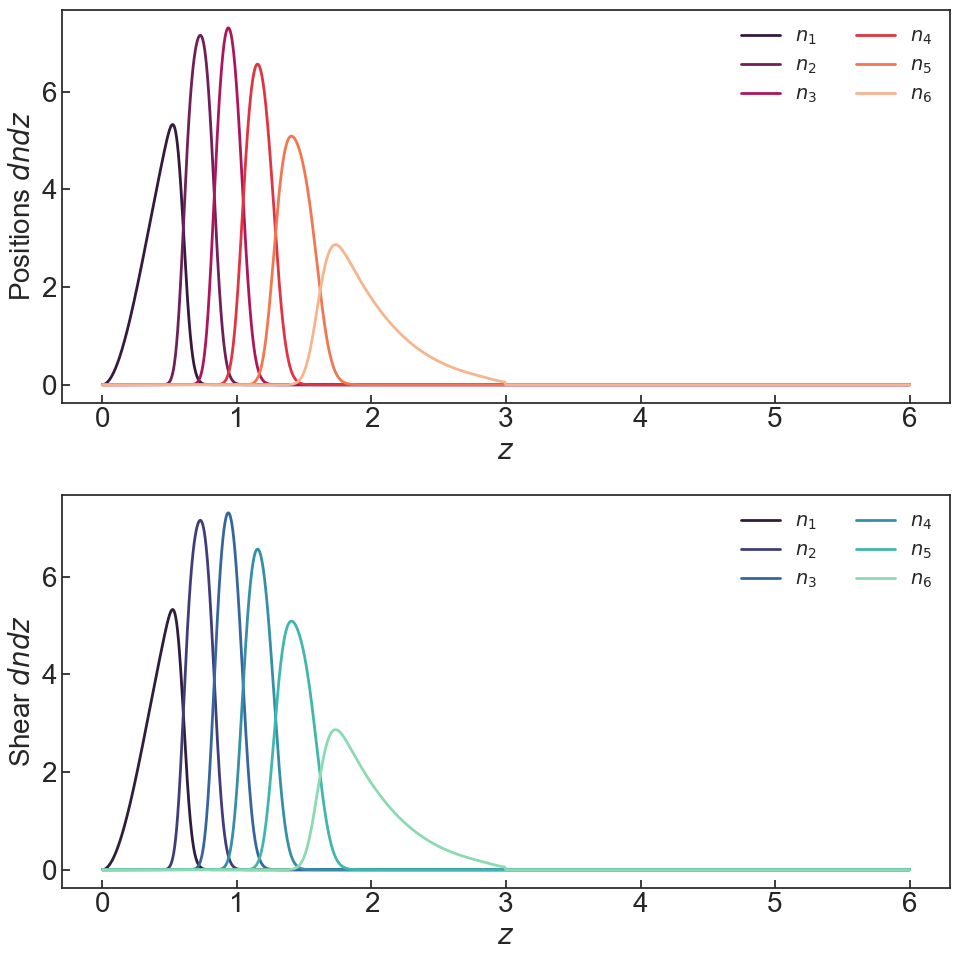

In [6]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in nz_heracles.keys():
    axs[0].plot(z_nz, nz_heracles[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", 6)[i])
    i=i+1
for key in nz_heracles.keys():
    axs[1].plot(z_nz, nz_heracles[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", 6)[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $dndz$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $dndz$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [7]:
# Normalise dndz
dndz_pos_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_pos_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z_nz)

dndz_she_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_she_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z_nz)


# Resampling the normalized n(z) with 300 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_pos_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_nz, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_she_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_she_norm[i,:] = np.interp(myz, z_nz, my_dndz_she[i,:])

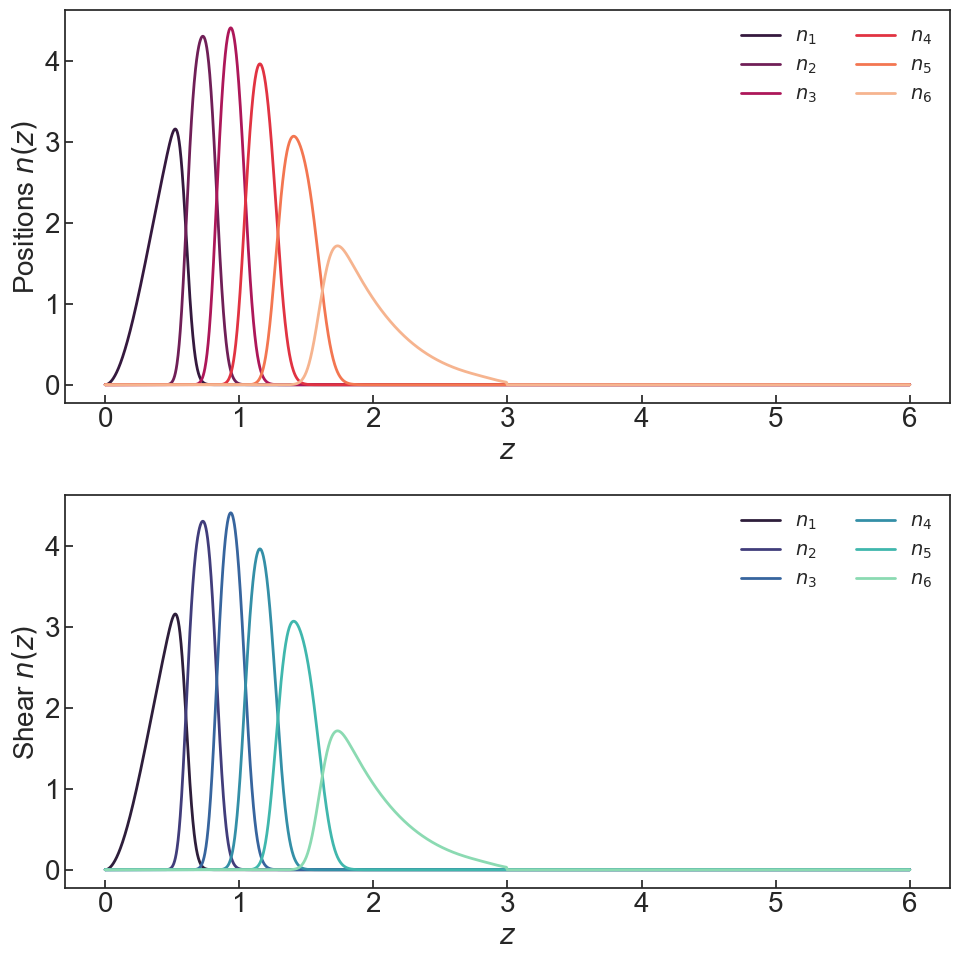

In [8]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in nz_heracles.keys():
    axs[0].plot(z_nz, dndz_pos_norm[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", 6)[i])
    i=i+1
for key in nz_heracles.keys():
    axs[1].plot(z_nz, dndz_she_norm[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", 6)[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

## Observables: shear and position tracers 

In [9]:
# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = myz,
                             galaxy_bias_model='poly', magnification_bias_model='None', 
                             nuisance_params={'b1_photo_poly0': 1, 'b1_photo_poly1': 0, 'b1_photo_poly2': 0, 'b1_photo_poly3': 0})

tracer_she = ShearTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_she_norm,
                             z = myz,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

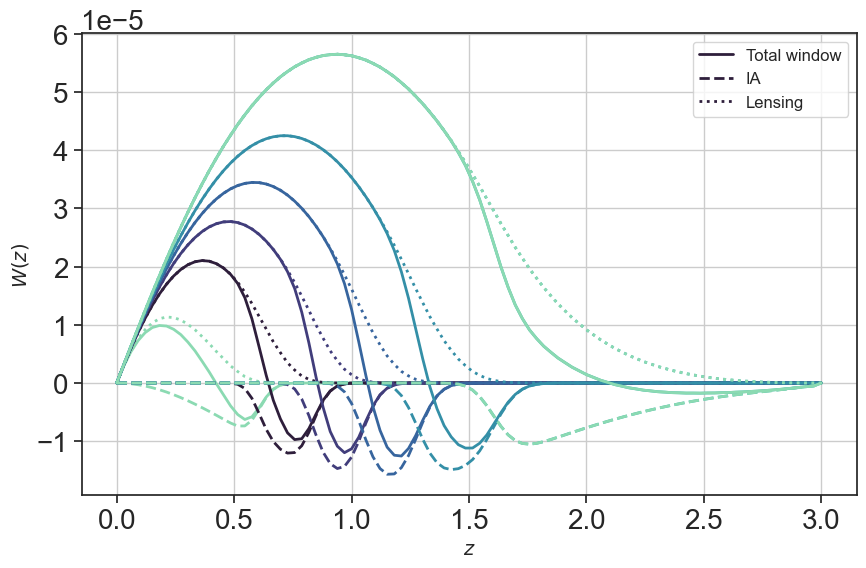

In [10]:
colors = sns.color_palette("mako", len(nz_heracles.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop
for i in range(0, 7):
    # Plot the window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_window_IA(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_lensing_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$W(z)$', fontsize=14)

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


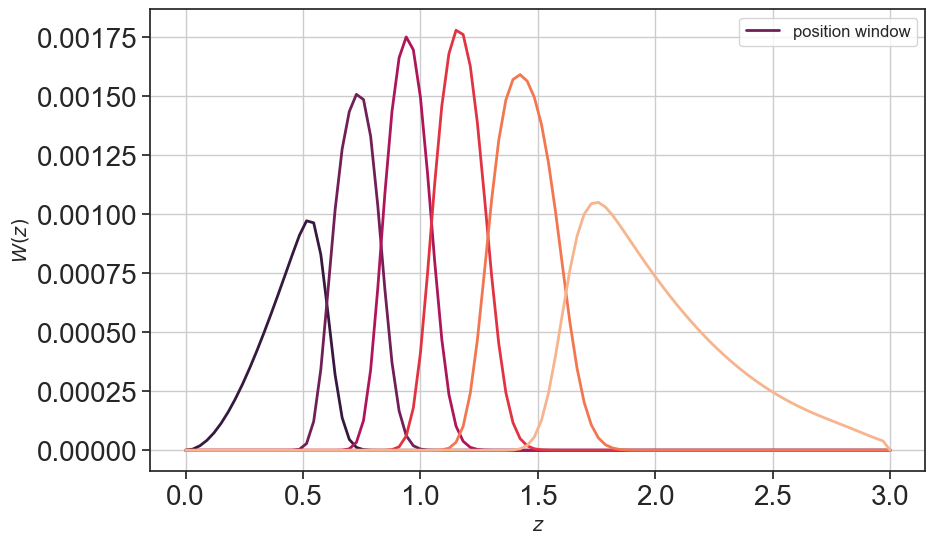

In [11]:
colors = sns.color_palette("rocket", len(nz_heracles.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop
for i in range(0, 6):
    # Plot the window
    plt.plot(nonlinear_perturbations.z, 
             tracer_pos.get_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i], 
             label=f'position window' if i == 1 else "")
    

# Label the axes
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$W(z)$', fontsize=14)

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

## Angular power spectra

### Theoretical Predictions

In [12]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_posshe = AngularTwoPoint(tracer_pos, tracer_she)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells_GG = twopoint_pospos.get_Cl(ells, 0, nonlinear_perturbations.k)
cells_GGL = twopoint_shepos.get_Cl(ells, 0, nonlinear_perturbations.k)
cells_EE = twopoint_sheshe.get_Cl(ells, 0, nonlinear_perturbations.k)

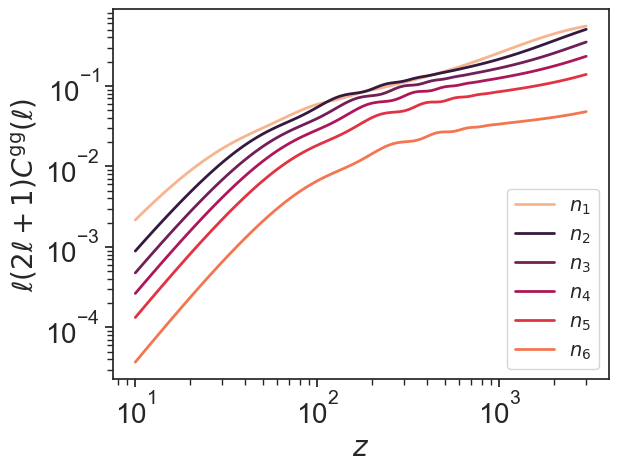

In [13]:
%timeit
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_GG[:, i, i], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_heracles.keys()))[i-1])
plt.xlabel(r'$z$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

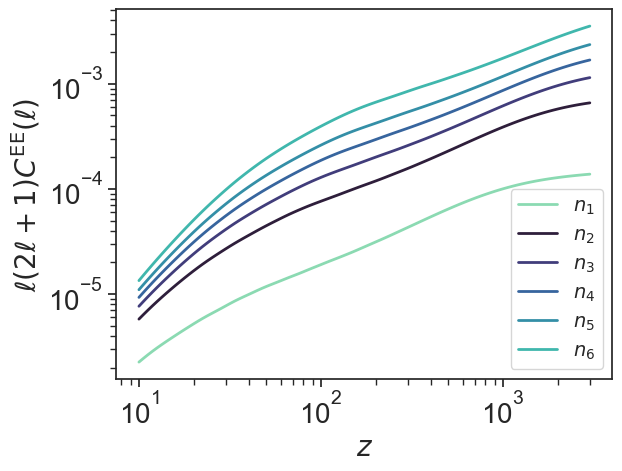

In [14]:
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_EE[:, i, i], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("mako", len(nz_heracles.keys()))[i-1])
plt.xlabel(r'$z$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm EE}(\ell)$');
plt.legend(fontsize=14);

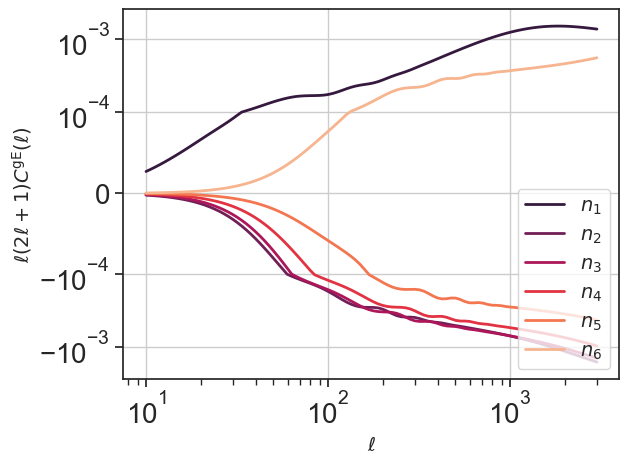

In [15]:
for i in range(0, 6):
    plt.plot(ells, 
             ells * (2 * ells + 1) * cells_GGL[:, i, i],
             label=f'$n_{{{i+1}}}$', 
             linewidth=2, 
             color=sns.color_palette("rocket", len(nz_heracles.keys()))[i])

# Labels and legend
plt.xlabel(r'$\ell$', fontsize=14)
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$', fontsize=14)
plt.legend(fontsize=14, loc=4)

# Set y-axis to symmetric log scale to handle negative values
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')
# Show the grid and the plot
plt.grid(True)
plt.show()

### Data vectors

In [16]:
import fitsio, re
from numpy.typing import NDArray, DTypeLike
from typing import Any

In [17]:
fits = fitsio.FITS('/Users/pedro/Downloads/cls.fits')

In [18]:
cells_data={}
for hdu in fits[1:]:
    data_temp = hdu.read()
    ell_cell = data_temp['ELL']
    name = hdu.get_extname().split('-')
    cells_data[name[0],name[1],int(name[2])-1,int(name[3])-1]=np.asarray(data_temp['ARRAY'],dtype=float)

In [19]:
#fits_mixmat = fitsio.FITS('/Users/pedro/Documents/GitHub/cloelib/example-mixmats (2).fits')
fits_mixmat = fitsio.FITS('/Users/pedro/Downloads/example-mixmats-final-v2.fits')

In [20]:
mixmat={}
for hdu in fits_mixmat[1:]:
    data_temp = hdu.read()
    ell_mixmat = data_temp['ELL']
    name = hdu.get_extname().split('-')
    mixmat[name[0],name[1],int(name[2])-1,int(name[3])-1]=np.asarray(data_temp['ARRAY'],dtype=float)

In [21]:
cells_PP = twopoint_pospos.get_pseudo_Cl(0, nonlinear_perturbations.k,mixmat)

(1, 1500)

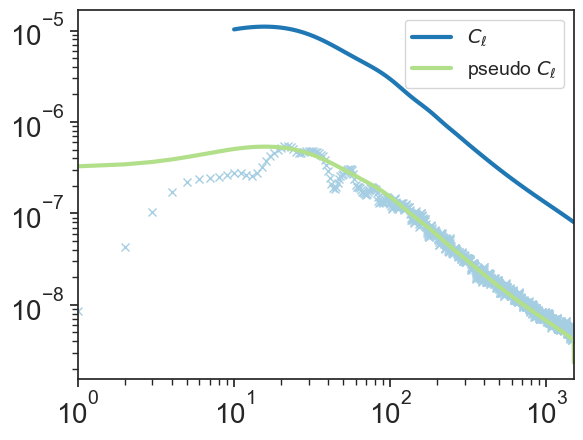

In [22]:
plt.loglog(ell_cell,cells_data['POS','POS',0,0],'x')
plt.loglog(ells,cells_GG[:,0,0],label='$C_\ell$')
plt.loglog(ell_mixmat,cells_PP['POS','POS',0,0],label='pseudo $C_\ell$')

plt.legend()
plt.xlim([1,1500])

In [23]:
cells_SS = twopoint_sheshe.get_pseudo_Cl(nl, nonlinear_perturbations.k,mixmat)

(2, 1500)

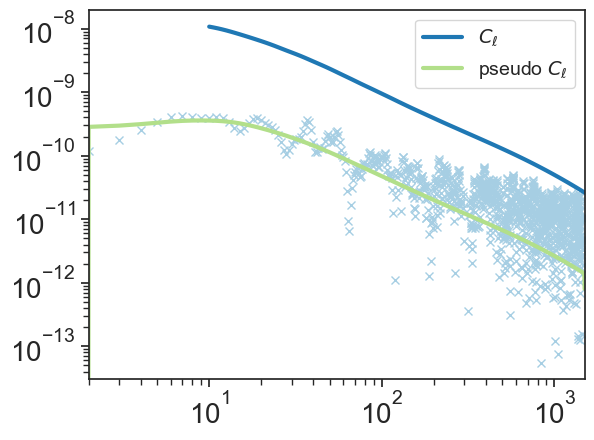

In [24]:
plt.loglog(ell_cell,cells_data['SHE','SHE',0,0][:,0],'x')
plt.loglog(ells,cells_EE[:,0,0],label='$C_\ell$')
plt.loglog(ell_mixmat,cells_SS['SHE','SHE',0,0][0],label='pseudo $C_\ell$')

plt.legend()
plt.xlim([2,1500])

In [25]:
cells_PS = twopoint_shepos.get_pseudo_Cl(nl, nonlinear_perturbations.k,mixmat)

(-1.5e-08, 1.5e-08)

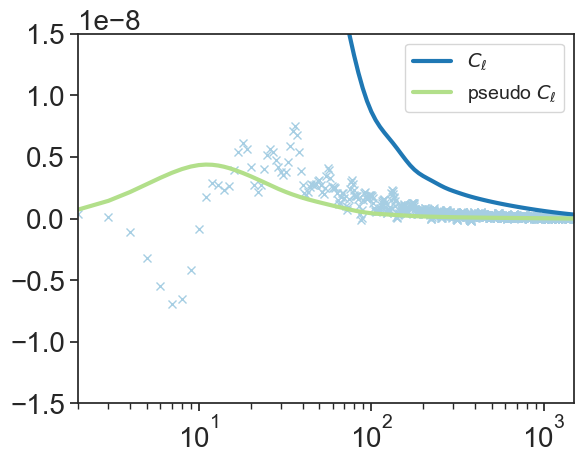

In [26]:
plt.semilogx(ell_cell,-cells_data['POS','SHE',0,0][:,0],'x')
plt.semilogx(ells,cells_GGL[:,0,0],label='$C_\ell$')
plt.semilogx(ell_mixmat,cells_PS['POS','SHE',0,0],label='pseudo $C_\ell$')

plt.legend()
plt.xlim([2,1500])
plt.ylim([-0.15e-7,0.15e-7])

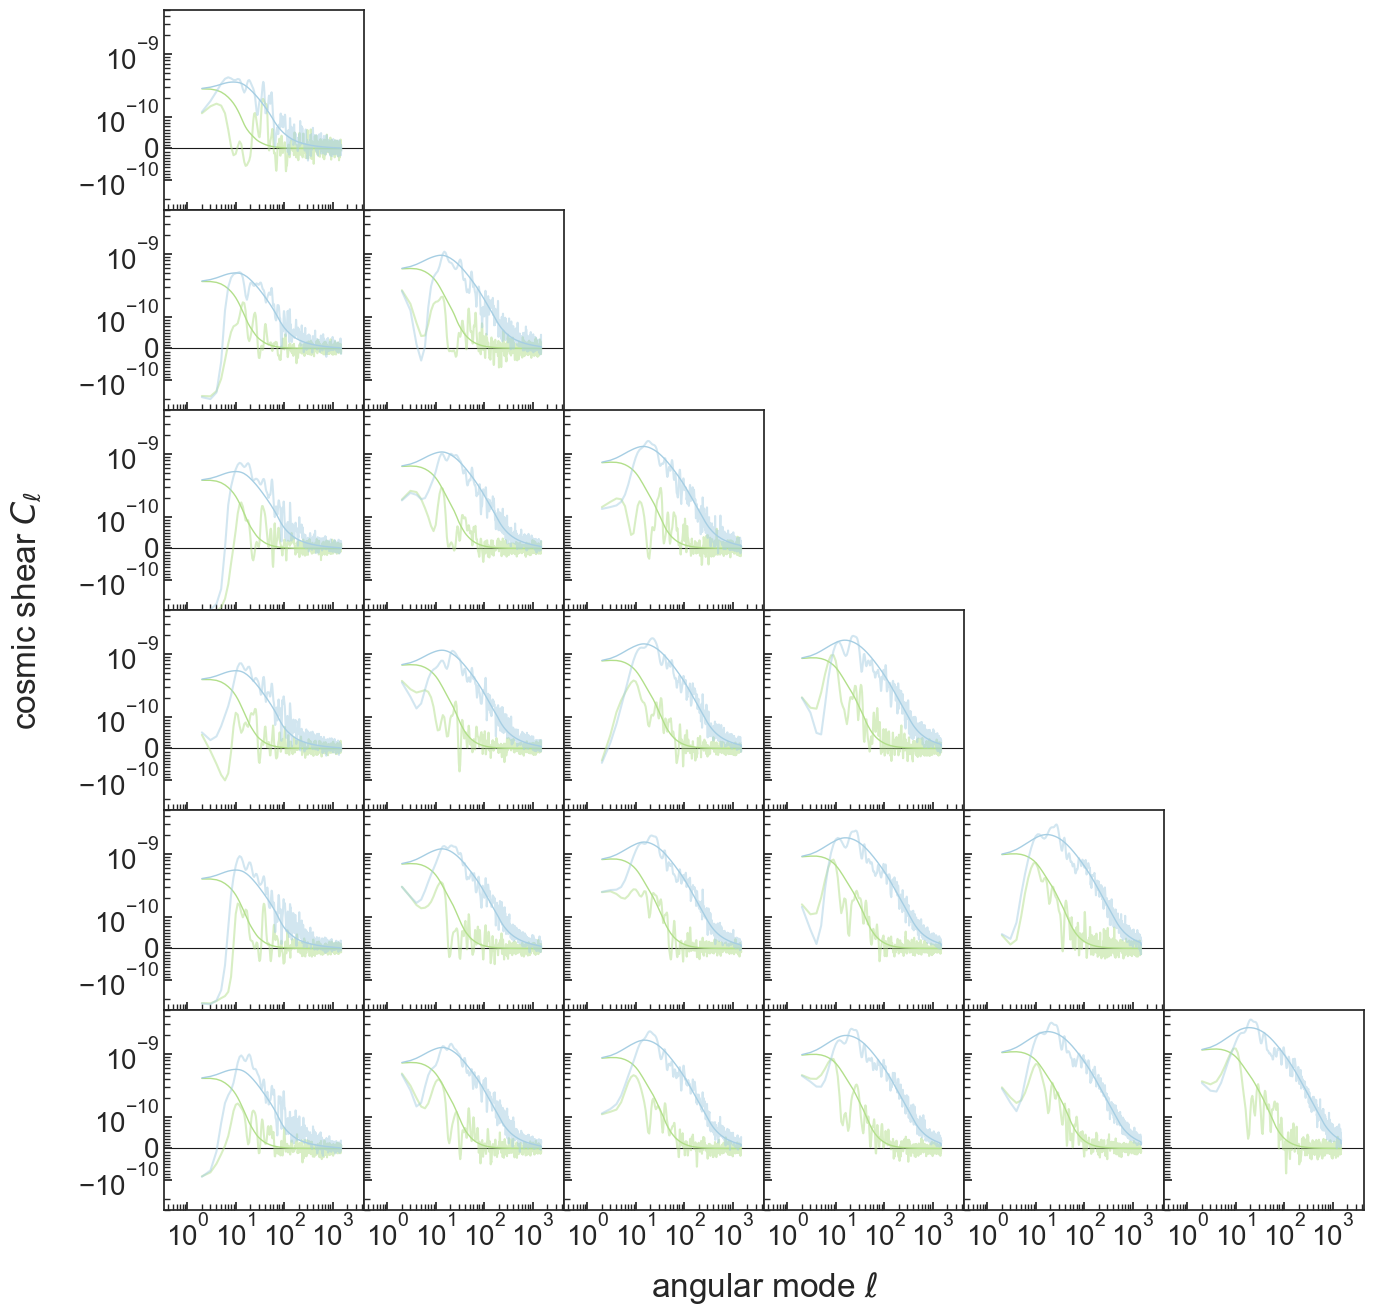

In [27]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            ell_cell[2:],
            cells_data["SHE", "SHE", i-1, j-1][2:,0],
            c="C0",
            lw=1.5,
            zorder=3.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            ell_mixmat[2:], cells_SS["SHE", "SHE", i-1, j-1][0, 2:], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            ell_cell[2:],
            cells_data["SHE", "SHE", i-1, j-1][2:,1],
            c="C2",
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            ell_mixmat[2:], cells_SS["SHE", "SHE", i-1, j-1][1, 2:], c="C2", lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-9)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

### Test timing

In [28]:
%%time

zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_values_linear = linear_perturbations.matter_power_spectrum(linear_perturbations.z,linear_perturbations.k)

nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = 'mead2020_feedback')
pk_values_nonlinear = nonlinear_perturbations.matter_power_spectrum(nonlinear_perturbations.z,nonlinear_perturbations.k)

# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = nonlinear_perturbations.z,
                             galaxy_bias_model='poly', magnification_bias_model='None', 
                             nuisance_params={'b1_photo_poly0': 1, 'b1_photo_poly1': 0, 'b1_photo_poly2': 0, 'b1_photo_poly3': 0})

tracer_she = ShearTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_she_norm,
                             z = nonlinear_perturbations.z,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells_GG_camb = twopoint_pospos.get_pseudo_Cl(0, nonlinear_perturbations.k,mixmat)
cells_GGL_camb = twopoint_shepos.get_pseudo_Cl(0, nonlinear_perturbations.k,mixmat)
cells_WL_camb = twopoint_sheshe.get_pseudo_Cl(0, nonlinear_perturbations.k,mixmat)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
CPU times: user 23.2 s, sys: 739 ms, total: 24 s
Wall time: 4.85 s


In [29]:
%%time

zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu,zs,log10TAGN=7.8)


pk_values_linear_emu = linear_perturbations_emu.matter_power_spectrum(linear_perturbations_emu.z,linear_perturbations_emu.k)

pk_values_nonlinear_emu = nonlinear_perturbations_emu.matter_power_spectrum(nonlinear_perturbations_emu.z,nonlinear_perturbations_emu.k)

# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_pos_norm,
                             z = myz,
                             galaxy_bias_model='poly', magnification_bias_model='None', 
                             nuisance_params={'b1_photo_poly0': 1, 'b1_photo_poly1': 0, 'b1_photo_poly2': 0, 'b1_photo_poly3': 0})

tracer_she = ShearTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_she_norm,
                             z = myz,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells_GG_emu = twopoint_pospos.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)
cells_GGL_emu = twopoint_shepos.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)
cells_WL_emu = twopoint_sheshe.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat)

CPU times: user 1.35 s, sys: 2.07 s, total: 3.41 s
Wall time: 820 ms


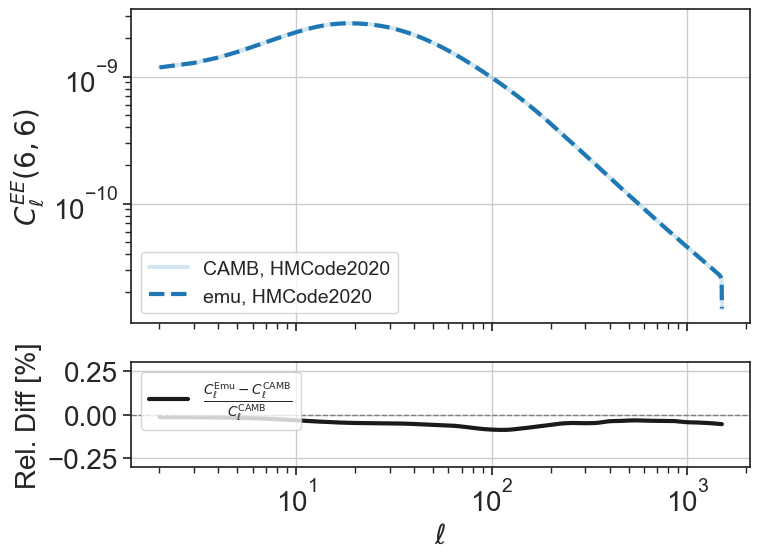

In [30]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

bin_plot = 6

# First plot: Power spectra
ax[0].loglog(ell_cell[2:],cells_WL_camb['SHE','SHE',bin_plot-1,bin_plot-1][0,2:], label='CAMB, HMCode2020', alpha=0.5)
ax[0].loglog(ell_cell[2:],cells_WL_emu['SHE','SHE',bin_plot-1,bin_plot-1][0,2:], '--', label='emu, HMCode2020')
ax[0].set_ylabel(r'$C_\ell^{EE}(%d,%d)$'%(bin_plot,bin_plot))
ax[0].legend()
ax[0].grid()

relative_diff = 100*(cells_WL_emu['SHE','SHE',bin_plot-1,bin_plot-1][0,2:] - cells_WL_camb['SHE','SHE',bin_plot-1,bin_plot-1][0,2:]) / cells_WL_camb['SHE','SHE',bin_plot-1,bin_plot-1][0,2:]

# Second plot: Relative difference
ax[1].semilogx(ell_cell[2:], relative_diff, 'k-', label=r'$\frac{C_\ell^{\mathrm{Emu}} - C_\ell^{\mathrm{CAMB}}}{C_\ell^{\mathrm{CAMB}}}$')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$\ell$ ')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()
ax[1].set_ylim([-0.3,0.3])

plt.tight_layout()
plt.show()


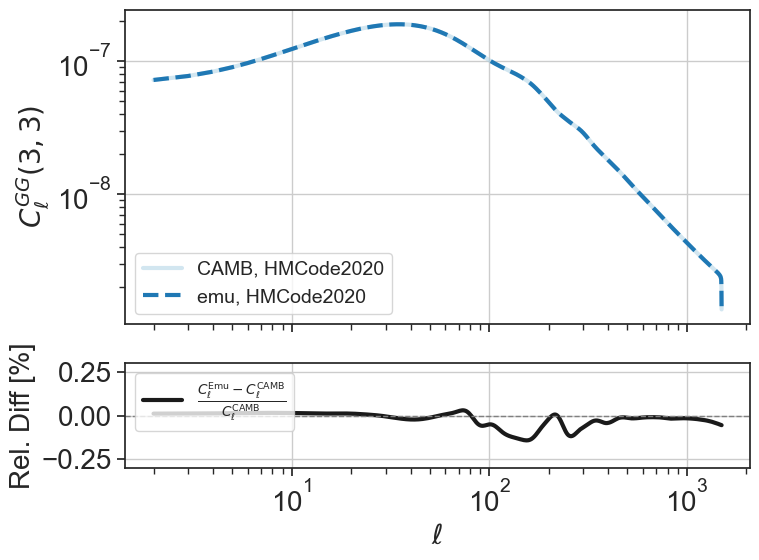

In [31]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

bin_plot = 3

# First plot: Power spectra
ax[0].loglog(ell_cell[2:],cells_GG_camb['POS','POS',bin_plot-1,bin_plot-1][2:], label='CAMB, HMCode2020', alpha=0.5)
ax[0].loglog(ell_cell[2:],cells_GG_emu['POS','POS',bin_plot-1,bin_plot-1][2:], '--', label='emu, HMCode2020')

ax[0].set_ylabel(r'$C_\ell^{GG}(%d,%d)$'%(bin_plot,bin_plot))
ax[0].legend()
ax[0].grid()

relative_diff = 100*(cells_GG_emu['POS','POS',bin_plot-1,bin_plot-1][2:] - cells_GG_camb['POS','POS',bin_plot-1,bin_plot-1][2:]) / cells_GG_camb['POS','POS',bin_plot-1,bin_plot-1][2:]

# Second plot: Relative difference
ax[1].semilogx(ell_cell[2:], relative_diff, 'k-', label=r'$\frac{C_\ell^{\mathrm{Emu}} - C_\ell^{\mathrm{CAMB}}}{C_\ell^{\mathrm{CAMB}}}$')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$\ell$ ')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()
ax[1].set_ylim([-0.3,0.3])

plt.tight_layout()
plt.show()


## Test bias models

In [32]:
zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            gamma_MG = 0.545)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu,zs,log10TAGN=7.8)


pk_values_linear_emu = linear_perturbations_emu.matter_power_spectrum(linear_perturbations_emu.z,linear_perturbations_emu.k)

pk_values_nonlinear_emu = nonlinear_perturbations_emu.matter_power_spectrum(nonlinear_perturbations_emu.z,nonlinear_perturbations_emu.k)

# Define the tracers

tracer_pos_per_bin = PositionsTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_pos_norm,
                             z = myz,
                             galaxy_bias_model='per_bin', magnification_bias_model='None', 
                             nuisance_params={'b1_photo_bin0': 1, 'b1_photo_bin1': 1.3,'b1_photo_bin2': 1.6,
                                              'b1_photo_bin3': 1.8,'b1_photo_bin4': 2,'b1_photo_bin5': 2.3}
                             )

tracer_pos_per_bin_int = PositionsTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_pos_norm,
                             z = myz,
                             galaxy_bias_model='per_bin_int', magnification_bias_model='None', 
                             nuisance_params={'b1_photo_bin0': 1, 'b1_photo_bin1': 1.3,'b1_photo_bin2': 1.6,
                                              'b1_photo_bin3': 1.8,'b1_photo_bin4': 2,'b1_photo_bin5': 2.3}
                             )

tracer_pos_poly = PositionsTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_pos_norm,
                             z = myz,
                             galaxy_bias_model='poly', magnification_bias_model='None', 
                             nuisance_params={'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
                                              'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913}
                             )

twopoint_pospos_per_bin = AngularTwoPoint(tracer_pos_per_bin, tracer_pos_per_bin)
twopoint_pospos_per_bin_int = AngularTwoPoint(tracer_pos_per_bin_int, tracer_pos_per_bin_int)
twopoint_pospos_poly = AngularTwoPoint(tracer_pos_poly, tracer_pos_poly)

cells_GG_emu_per_bin = twopoint_pospos_per_bin.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)
cells_GG_emu_per_bin_int = twopoint_pospos_per_bin_int.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)
cells_GG_emu_poly = twopoint_pospos_poly.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)
#cells_GGL_emu = twopoint_shepos.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)


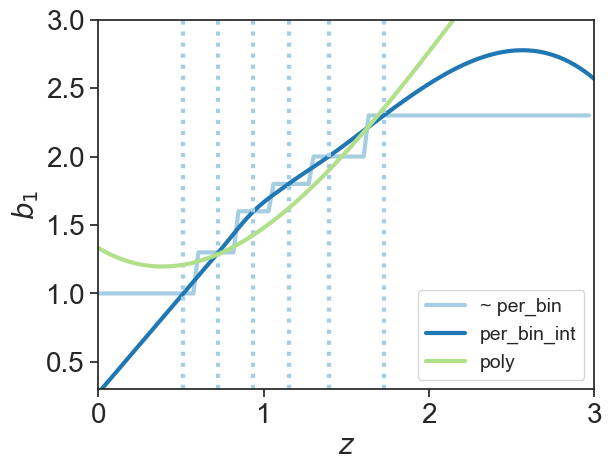

In [33]:
plt.plot(zs[:-1],tracer_pos_per_bin.bias_array[np.argmax(my_dndz_pos_norm,axis=0)][:-1],label='~ per_bin')
plt.plot(zs,tracer_pos_per_bin_int.bias_array,label='per_bin_int')
z_max_bin = zs[np.argmax(my_dndz_pos_norm,axis=1)]
for z_mbin in z_max_bin:
    plt.axvline(z_mbin,ls=':')

plt.plot(zs,tracer_pos_poly.bias_array,label='poly')
plt.xlabel('$z$')
plt.ylabel('$b_1$')
plt.xlim([0,3])
plt.ylim([0.3,3])

plt.legend()


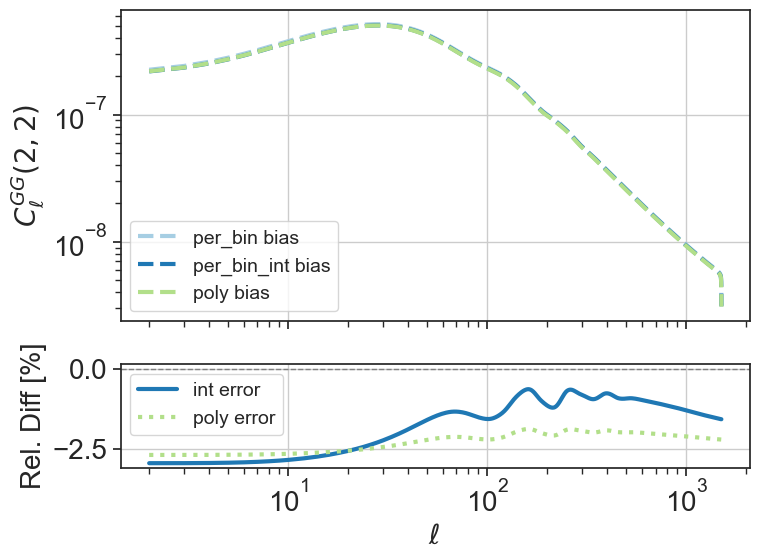

In [38]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

bin_plot = 2

# First plot: Power spectra
ax[0].loglog(ell_cell[2:],cells_GG_emu_per_bin['POS','POS',bin_plot-1,bin_plot-1][2:], '--', label='per_bin bias')
ax[0].loglog(ell_cell[2:],cells_GG_emu_per_bin_int['POS','POS',bin_plot-1,bin_plot-1][2:], '--', label='per_bin_int bias')
ax[0].loglog(ell_cell[2:],cells_GG_emu_poly['POS','POS',bin_plot-1,bin_plot-1][2:], '--', label='poly bias')

ax[0].set_ylabel(r'$C_\ell^{GG}(%d,%d)$'%(bin_plot,bin_plot))
ax[0].legend()
ax[0].grid()

relative_diff1 = 100*(cells_GG_emu_per_bin_int['POS','POS',bin_plot-1,bin_plot-1][2:] - cells_GG_emu_per_bin['POS','POS',bin_plot-1,bin_plot-1][2:]) / cells_GG_emu_per_bin['POS','POS',bin_plot-1,bin_plot-1][2:]
relative_diff2 = 100*(cells_GG_emu_poly['POS','POS',bin_plot-1,bin_plot-1][2:] - cells_GG_emu_per_bin['POS','POS',bin_plot-1,bin_plot-1][2:]) / cells_GG_emu_per_bin['POS','POS',bin_plot-1,bin_plot-1][2:]

# Second plot: Relative difference
ax[1].semilogx(ell_cell[2:], relative_diff1, 'C1-', label=r'int error')
ax[1].semilogx(ell_cell[2:], relative_diff2, 'C2:', label=r'poly error')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$\ell$ ')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()
#ax[1].set_ylim([-0.3,0.3])

plt.tight_layout()
plt.show()


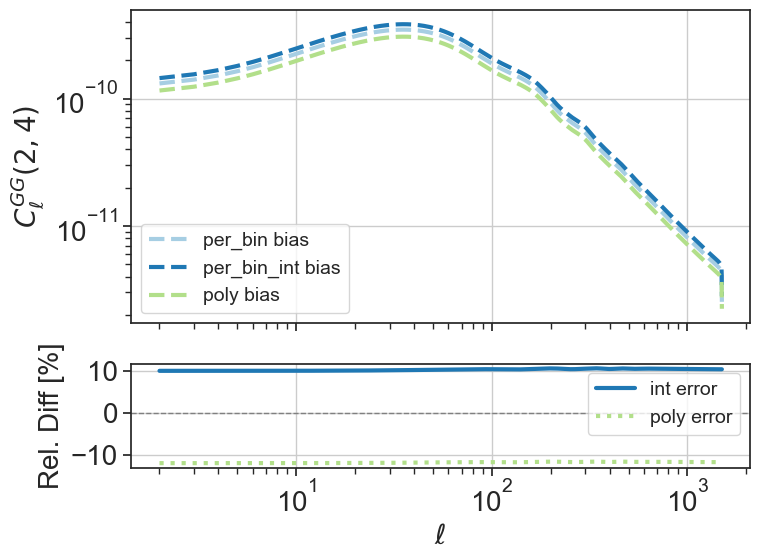

In [37]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

bin_plot = 4

# First plot: Power spectra
ax[0].loglog(ell_cell[2:],cells_GG_emu_per_bin['POS','POS',1,bin_plot-1][2:], '--', label='per_bin bias')
ax[0].loglog(ell_cell[2:],cells_GG_emu_per_bin_int['POS','POS',1,bin_plot-1][2:], '--', label='per_bin_int bias')
ax[0].loglog(ell_cell[2:],cells_GG_emu_poly['POS','POS',1,bin_plot-1][2:], '--', label='poly bias')

ax[0].set_ylabel(r'$C_\ell^{GG}(%d,%d)$'%(2,bin_plot))
ax[0].legend()
ax[0].grid()

relative_diff1 = 100*(cells_GG_emu_per_bin_int['POS','POS',1,bin_plot-1][2:] - cells_GG_emu_per_bin['POS','POS',1,bin_plot-1][2:]) / cells_GG_emu_per_bin['POS','POS',1,bin_plot-1][2:]
relative_diff2 = 100*(cells_GG_emu_poly['POS','POS',1,bin_plot-1][2:] - cells_GG_emu_per_bin['POS','POS',1,bin_plot-1][2:]) / cells_GG_emu_per_bin['POS','POS',1,bin_plot-1][2:]

# Second plot: Relative difference
ax[1].semilogx(ell_cell[2:], relative_diff1, 'C1-', label=r'int error')
ax[1].semilogx(ell_cell[2:], relative_diff2, 'C2:', label=r'poly error')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$\ell$ ')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()
#ax[1].set_ylim([-0.3,0.3])

plt.tight_layout()
plt.show()
